In [2]:
import pandas as pd

from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import RMSprop

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import classification_report, confusion_matrix

### Visualizando os dados

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
import random
x_teste_final = random.choice(x_test)

In [5]:
# Pegando valores para testar
x_teste_final = x_test[-5:]
y_teste_final = y_test[-5:]

x_test = x_test[:-5]
y_test = y_test[:-5]

In [ ]:
# Cada dado é uma matriz 28x28
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

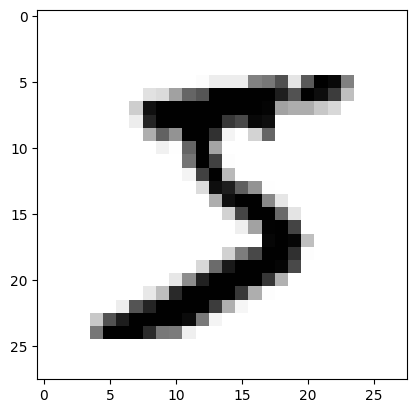

Label: 5


In [19]:
plt.imshow(x_train[0].reshape(28,28), cmap=plt.cm.binary)
plt.show()
print('Label: {}'.format(y_train[0]))

In [20]:
# As classes
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [21]:
numero_classes = len(set(y_train))

In [22]:
# Valores precisam estar no formato one-hot encoding
# 1 -> [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
y_train = keras.utils.to_categorical(y_train, numero_classes)
y_test = keras.utils.to_categorical(y_test, numero_classes)

### Criando a CNN

In [ ]:
# Criando o modelo Sequential
# Sequential: Modelo Keras de ir adicionando camadas
# Conv2D: Camada com kernels (filtros) que percorrem a imagem extraindo caracterísitcas (mapas de caracteísticas)
# MaxPooling2D: Camada que reduz a dimensionalidade dos mapas de características 2D
# Flatten: Camada que transforma um mapa de características 2D num vetor para classficador final
# Dense: Camada onde todas as entradas estão conectadas em cada neurônio (totalmente conectada)
# Dropout: Camada usa durante treino que descarta aleatoriamente um percentual de conexões (reduz overfitting)

model = Sequential()
model.add(Conv2D(20, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(40, kernel_size=(3,3), activation='relu'))
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.2)) ## Desliga neuronios que não contribuem para a classificação
model.add(Dense(numero_classes, activation='softmax'))
model.summary()

/workspaces/ml-supervised-dev/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-08-19 00:22:16.586239: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 20)     │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 40)     │         7,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │       242,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,000 (976.56 KB)

 Trainable params: 250,000 (976.56 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Compila o modelo
model.compile(loss='categorical_crossentropy',# <- Usada para classificação multiclasse
              optimizer=RMSprop(), # <- Adaptação do Gradiente Descendente. Usado para gradientes com diferentes magnitudes
              metrics=['accuracy'])

In [25]:
# Treina com os parte dos dados
batch_size = 32 # <- Quantidade de dados por iteração
epochs = 20 ## quantos iterações vai usar

#Salvar o melhor modelo. Se não reduzir o erro em 10 iterações salva o melhor
callbacks_list = [
    keras.callbacks.ModelCheckpoint(
        filepath='../artifacts/model.h5', # <- Formato usado para salvar os pesos da rede
        monitor='val_loss', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,verbose=1)
]

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    callbacks = callbacks_list,
                    verbose=1,
                    validation_data=(x_test, y_test))

Epoch 1/20


2025-08-19 00:27:58.577864: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 47040000 exceeds 10% of free system memory.


1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8765 - loss: 0.7408
Epoch 1: val_loss improved from inf to 0.09467, saving model to ../artifacts/model.h5


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.8766 - loss: 0.7401 - val_accuracy: 0.9712 - val_loss: 0.0947
Epoch 2/20
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9721 - loss: 0.1066
Epoch 2: val_loss improved from 0.09467 to 0.07436, saving model to ../artifacts/model.h5


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9721 - loss: 0.1066 - val_accuracy: 0.9798 - val_loss: 0.0744
Epoch 3/20
1871/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9764 - loss: 0.0913
Epoch 3: val_loss did not improve from 0.07436
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - accuracy: 0.9764 - loss: 0.0913 - val_accuracy: 0.9803 - val_loss: 0.0769
Epoch 4/20
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9800 - loss: 0.0826
Epoch 4: val_loss improved from 0.07436 to 0.07233, saving model to ../artifacts/model.h5


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - accuracy: 0.9800 - loss: 0.0826 - val_accuracy: 0.9825 - val_loss: 0.0723
Epoch 5/20
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9825 - loss: 0.0723
Epoch 5: val_loss did not improve from 0.07233
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9825 - loss: 0.0723 - val_accuracy: 0.9776 - val_loss: 0.0971
Epoch 6/20
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9825 - loss: 0.0801
Epoch 6: val_loss did not improve from 0.07233
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - accuracy: 0.9825 - loss: 0.0801 - val_accuracy: 0.9850 - val_loss: 0.0854
Epoch 7/20
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9828 - loss: 0.0795
Epoch 7: val_loss did not improve from 0.07233
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9828 - loss: 0.0795 - val_accuracy: 0.9846 - val_loss: 0.0903
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9819 - loss: 0.0818
Epoch 8: val_loss d

In [13]:
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.18622291088104248
Test accuracy: 0.9785892963409424


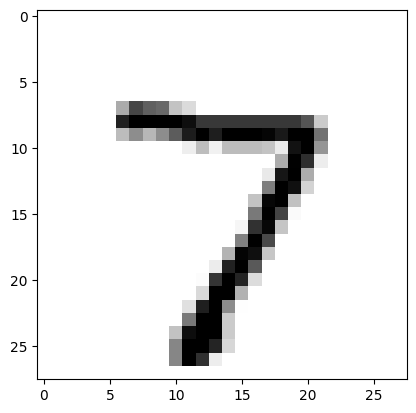

Label: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [14]:
plt.imshow(x_test[0].reshape(28,28), cmap=plt.cm.binary)
plt.show()
print('Label: {}'.format(y_test[0]))

In [15]:
import numpy as np
print(y_test[0])
prediction = model.predict(x_test[0].reshape((1,28,28,1)))
predicted_classes = np.argmax(prediction, axis=-1)
predicted_classes

[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


array([7])